In [50]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
import re
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
from collections import Counter

In [52]:
def load_data(filepath):
    """Read tab-separated English\tFrench pairs, return two lists of raw strings."""
    src_sentences = []
    tgt_sentences = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:          # skip blank lines
                continue
            parts = line.split('\t')
            if len(parts) < 2:    # skip malformed lines
                continue
            src_sentences.append(parts[0])
            tgt_sentences.append(parts[1])

    return src_sentences, tgt_sentences


def preprocess(sentence):
    """
    Lowercase, strip leading/trailing whitespace.
    We do NOT split apostrophes (J'ai stays as one token).
    and do not strip accents (é, à, ê ).
    """
    sentence = sentence.lower().strip()
    return sentence


def tokenize(sentence):
    """Split on whitespace. Returns a list of word tokens."""
    return sentence.split()

filepath = '/content/drive/MyDrive/Deep-Learning/datasets/vast_english_french.txt'

raw_src, raw_tgt = load_data(filepath)

# preprocess and tokenize
src_tokens = [tokenize(preprocess(s)) for s in raw_src]
tgt_tokens = [tokenize(preprocess(t)) for t in raw_tgt]

print(f"Total sentence pairs:{len(src_tokens)}")
print(f"\nSample pairs:")
for i in range(5):
    print(f"English: {src_tokens[i]}")
    print(f"French: {tgt_tokens[i]}")
    print()

Total sentence pairs:555

Sample pairs:
English: ['i', 'am', 'cold']
French: ["j'ai", 'froid']

English: ['you', 'are', 'tired']
French: ['tu', 'es', 'fatigué']

English: ['he', 'is', 'hungry']
French: ['il', 'a', 'faim']

English: ['she', 'is', 'happy']
French: ['elle', 'est', 'heureuse']

English: ['we', 'are', 'friends']
French: ['nous', 'sommes', 'amis']



In [53]:


(src_train, src_val,tgt_train, tgt_val) = train_test_split(src_tokens, tgt_tokens,test_size=0.2,random_state=42)

print(f"Train pairs:{len(src_train)}")
print(f"Val pairs:{len(src_val)}")

# Inspect length distribution
src_lengths = [len(s) for s in src_tokens]
tgt_lengths = [len(t) for t in tgt_tokens]

print(f"English lengths—min: {min(src_lengths)}, max: {max(src_lengths)}, "
      f"mean: {np.mean(src_lengths):.1f}, 95th pct: {np.percentile(src_lengths, 95):.0f}")
print(f"French lengths   — min: {min(tgt_lengths)}, max: {max(tgt_lengths)}, "
      f"mean: {np.mean(tgt_lengths):.1f}, 95th pct: {np.percentile(tgt_lengths, 95):.0f}")


Train pairs:444
Val pairs:111
English lengths—min: 3, max: 10, mean: 6.3, 95th pct: 9
French lengths   — min: 2, max: 14, mean: 6.8, 95th pct: 10


In [54]:
# Build vocabulary: vocab is built from TRAINING data only

class Vocabulary:
    """Maps tokens to integer indices. Special tokens always at fixed positions."""

    PAD_IDX = 0    # padding
    BOS_IDX = 1    # beginning of sequence
    EOS_IDX = 2    # end of sequence
    UNK_IDX = 3    # unknown word

    def __init__(self, name):
        self.name = name
        self.token2idx = {
            '<pad>': self.PAD_IDX,
            '<bos>': self.BOS_IDX,
            '<eos>': self.EOS_IDX,
            '<unk>': self.UNK_IDX,
        }
        self.idx2token = {v: k for k, v in self.token2idx.items()}

    def build(self, token_lists, min_freq=1):
        """
        Count all tokens across all sentences. Add tokens that appear at least min_freq times.
        """
        counter = Counter(token for tokens in token_lists for token in tokens)

        for token, freq in sorted(counter.items()):   # sorted for reproducibility
            if freq >= min_freq and token not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[token] = idx
                self.idx2token[idx] = token

        print(f"{self.name} vocab size: {len(self.token2idx)} "
              f"(including 4 special tokens)")

    def encode(self, tokens):
        """Convert list of tokens → list of indices. Unknown tokens → UNK_IDX."""
        return [self.token2idx.get(t, self.UNK_IDX) for t in tokens]

    def decode(self, indices, strip_special=True):
        """Convert list of indices → list of tokens."""
        tokens = [self.idx2token.get(i, '<unk>') for i in indices]
        if strip_special:
            tokens = [t for t in tokens
                      if t not in ('<pad>', '<bos>', '<eos>')]
        return tokens

    def __len__(self):
        return len(self.token2idx)


# build from training data only
src_vocab = Vocabulary('English')
src_vocab.build(src_train)

tgt_vocab = Vocabulary('French')
tgt_vocab.build(tgt_train)

English vocab size: 894 (including 4 special tokens)
French vocab size: 993 (including 4 special tokens)


In [55]:
# 7. Encode and pad sequences

NUM_STEPS = 15

def encode_and_pad(token_list, vocab, num_steps):
    """
    Encode tokens → indices, append <eos>, then pad or truncate to num_steps.
    Returns a list of fixed-length integer lists.
    """
    encoded = vocab.encode(token_list) + [vocab.EOS_IDX]   # append <eos>

    if len(encoded) < num_steps:
        # pad to num_steps
        encoded += [vocab.PAD_IDX] * (num_steps - len(encoded))
    else:
        # truncate to num_steps (keeps <eos> if it fits, otherwise drops it)
        encoded = encoded[:num_steps]

    return encoded


# encode all splits
src_train_enc = [encode_and_pad(s, src_vocab, NUM_STEPS) for s in src_train]
src_val_enc   = [encode_and_pad(s, src_vocab, NUM_STEPS) for s in src_val]

tgt_train_enc = [encode_and_pad(t, tgt_vocab, NUM_STEPS) for t in tgt_train]
tgt_val_enc   = [encode_and_pad(t, tgt_vocab, NUM_STEPS) for t in tgt_val]

# convert to tensors
src_train_t = torch.tensor(src_train_enc, dtype=torch.long)
src_val_t   = torch.tensor(src_val_enc,   dtype=torch.long)
tgt_train_t = torch.tensor(tgt_train_enc, dtype=torch.long)
tgt_val_t   = torch.tensor(tgt_val_enc,   dtype=torch.long)

print(f"src_train_t shape : {src_train_t.shape}")   # (N_train, num_steps)
print(f"tgt_train_t shape : {tgt_train_t.shape}")
print(f"src_val_t shape   : {src_val_t.shape}")
print(f"tgt_val_t shape   : {tgt_val_t.shape}")

src_train_t shape : torch.Size([444, 15])
tgt_train_t shape : torch.Size([444, 15])
src_val_t shape   : torch.Size([111, 15])
tgt_val_t shape   : torch.Size([111, 15])


In [56]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

train_dataset = TensorDataset(src_train_t, tgt_train_t)
val_dataset   = TensorDataset(src_val_t,   tgt_val_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
print(f"Train batches : {len(train_loader)}")   # 14 batches
print(f"Val batches   : {len(val_loader)}")     # 4 batches

Train batches : 14
Val batches   : 4


In [57]:
import torch.nn as nn

class Encoder(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size,padding_idx=Vocabulary.PAD_IDX)
        self.rnn = nn.GRU(embed_size, hidden_size,num_layers=num_layers,batch_first=True,dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (batch, num_steps)
        embedded = self.dropout(self.embedding(src))   # (batch, num_steps, embed_size)
        output, h_n = self.rnn(embedded)
        return output, h_n


In [58]:
class Decoder(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size,
                                      padding_idx=Vocabulary.PAD_IDX)
        self.rnn = nn.GRU(embed_size + hidden_size, hidden_size,
                          num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, context):
        tgt_token = tgt_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(tgt_token))
        ctx = context[-1].unsqueeze(1)
        rnn_input = torch.cat([embedded, ctx], dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        logits = self.fc(output.squeeze(1))
        return logits, hidden

In [59]:
import random

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        tgt_vocab_size = self.decoder.fc.out_features

        # store predictions at every time step
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        # encode source sequence
        enc_output, hidden = self.encoder(src)

        # context = encoder's final hidden state, reused at every decoder step
        context = hidden    # (num_layers, batch, hidden_size)

        # first decoder input is <bos> token for every sentence in the batch
        input_token = tgt[:, 0]   # (batch,) — should all be BOS_IDX

        for t in range(1, tgt_len):
            logits, hidden = self.decoder(input_token, hidden, context)
            outputs[:, t] = logits

            if random.random() < teacher_forcing_ratio:
                input_token = tgt[:, t]
            else:
                input_token = logits.argmax(1)

        return outputs

    def predict(self, src_tensor, max_len=20):
        self.eval()
        with torch.no_grad():
            _, hidden = self.encoder(src_tensor)
            context   = hidden

            # start with <bos>
            input_token = torch.tensor([Vocabulary.BOS_IDX]).to(self.device)
            predicted   = []

            for _ in range(max_len):
                logits, hidden = self.decoder(input_token, hidden, context)
                pred_idx = logits.argmax(1).item()

                if pred_idx == Vocabulary.EOS_IDX:
                    break

                predicted.append(pred_idx)
                input_token = torch.tensor([pred_idx]).to(self.device)

        return predicted

In [60]:
def masked_cross_entropy(logits, target, pad_idx=Vocabulary.PAD_IDX):

    batch_size, seq_len, vocab_size = logits.shape

    # flatten to (batch*seq_len, vocab_size) and (batch*seq_len,)
    logits_flat = logits.reshape(-1, vocab_size)
    target_flat = target.reshape(-1)

    # compute per-token loss (no reduction yet)
    loss_fn = nn.CrossEntropyLoss(reduction='none')
    loss    = loss_fn(logits_flat, target_flat)

    mask = (target_flat != pad_idx).float()

    masked_loss = (loss * mask).sum() / mask.sum()

    return masked_loss

In [61]:
EMBED_SIZE   = 128
HIDDEN_SIZE  = 256
NUM_LAYERS   = 1
DROPOUT      = 0.4
LEARNING_RATE = 0.001
N_EPOCHS     = 40

TEACHER_FORCING_START = 0.8
TEACHER_FORCING_END   = 0.2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")

encoder = Encoder(
    vocab_size  = len(src_vocab),
    embed_size  = EMBED_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(device)

decoder = Decoder(
    vocab_size  = len(tgt_vocab),
    embed_size  = EMBED_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(device)

model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
print(model)

Using cuda
Total trainable parameters: 1,286,241
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(894, 128, padding_idx=0)
    (rnn): GRU(128, 256, batch_first=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(993, 128, padding_idx=0)
    (rnn): GRU(384, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=993, bias=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
)


In [62]:
import time

train_losses     = []
val_losses       = []
train_accuracies = []
val_accuracies   = []

for epoch in range(N_EPOCHS):
    start = time.time()
    teacher_forcing_ratio = TEACHER_FORCING_START - (
        (TEACHER_FORCING_START - TEACHER_FORCING_END) * epoch / (N_EPOCHS - 1)
    )

    # ── Training
    model.train()
    epoch_loss    = 0.0
    correct_train = 0
    total_train   = 0

    for src_batch, tgt_batch in train_loader:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        optimizer.zero_grad()
        outputs = model(src_batch, tgt_batch, teacher_forcing_ratio=0.5)

        loss = masked_cross_entropy(outputs[:, 1:], tgt_batch[:, 1:])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()


        preds  = outputs[:, 1:].argmax(dim=-1) # (batch, num_steps-1)
        target = tgt_batch[:, 1:] # (batch, num_steps-1)
        mask   = (target != Vocabulary.PAD_IDX)
        correct_train += (preds == target)[mask].sum().item()
        total_train   += mask.sum().item()

    avg_train_loss = epoch_loss / len(train_loader)
    avg_train_acc  = 100.0 * correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)

    # ── Validation
    model.eval()
    val_loss      = 0.0
    correct_val   = 0
    total_val     = 0

    with torch.no_grad():
        for src_batch, tgt_batch in val_loader:
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            outputs = model(src_batch, tgt_batch,teacher_forcing_ratio=teacher_forcing_ratio)

            loss = masked_cross_entropy(outputs[:, 1:], tgt_batch[:, 1:])
            val_loss += loss.item()

            preds  = outputs[:, 1:].argmax(dim=-1)
            target = tgt_batch[:, 1:]
            mask   = (target != Vocabulary.PAD_IDX)
            correct_val += (preds == target)[mask].sum().item()
            total_val   += mask.sum().item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = 100.0 * correct_val / total_val
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1:>3}/{N_EPOCHS} | "
      f"TF: {teacher_forcing_ratio:.2f} | "
      f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | "
      f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.2f}% | "
      f"Time: {elapsed:.1f}s")

Epoch   1/40 | TF: 0.80 | Train Loss: 6.4036 | Train Acc: 10.76% | Val Loss: 5.8198 | Val Acc: 15.31% | Time: 0.4s
Epoch   2/40 | TF: 0.78 | Train Loss: 5.5912 | Train Acc: 15.65% | Val Loss: 5.8937 | Val Acc: 17.24% | Time: 0.3s
Epoch   3/40 | TF: 0.77 | Train Loss: 5.3452 | Train Acc: 17.13% | Val Loss: 5.8665 | Val Acc: 18.76% | Time: 0.3s
Epoch   4/40 | TF: 0.75 | Train Loss: 5.1331 | Train Acc: 18.12% | Val Loss: 5.8428 | Val Acc: 18.76% | Time: 0.4s
Epoch   5/40 | TF: 0.74 | Train Loss: 4.9449 | Train Acc: 18.97% | Val Loss: 5.7726 | Val Acc: 18.90% | Time: 0.3s
Epoch   6/40 | TF: 0.72 | Train Loss: 4.7556 | Train Acc: 20.18% | Val Loss: 5.6830 | Val Acc: 21.38% | Time: 0.3s
Epoch   7/40 | TF: 0.71 | Train Loss: 4.5838 | Train Acc: 21.56% | Val Loss: 5.5963 | Val Acc: 21.10% | Time: 0.4s
Epoch   8/40 | TF: 0.69 | Train Loss: 4.4319 | Train Acc: 22.35% | Val Loss: 5.5854 | Val Acc: 21.38% | Time: 0.3s
Epoch   9/40 | TF: 0.68 | Train Loss: 4.2517 | Train Acc: 23.43% | Val Loss: 5.5

In [63]:
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

def evaluate_and_show_examples(model, src_val_t, tgt_val_t,
                                src_vocab, tgt_vocab,
                                device, n_examples=5):
    model.eval()
    chencherry = SmoothingFunction()

    correct_exact = 0
    total_bleu    = 0.0
    all_references  = []
    all_hypotheses  = []

    print("\nGenerating Evaluation Examples")
    print(f"{'Input':<35} {'Target':<35} {'Predicted':<35} {'Match':<6} {'BLEU'}")
    print("-" * 120)

    with torch.no_grad():
        for i in range(len(src_val_t)):

            # single sentence — add batch dimension
            src_tensor = src_val_t[i].unsqueeze(0).to(device)  # (1, num_steps)

            # greedy decode
            pred_indices = model.predict(src_tensor, max_len=NUM_STEPS)

            # decode source back to words (for display)
            src_words  = src_vocab.decode(src_val_t[i].tolist())

            # decode target (ground truth)
            tgt_words  = tgt_vocab.decode(tgt_val_t[i].tolist())

            # decode prediction
            pred_words = tgt_vocab.decode(pred_indices)

            # ── Evaluation 1: Exact Match ─────────────────────────────────
            exact_match = (pred_words == tgt_words)
            if exact_match:
                correct_exact += 1

            # ── Evaluation 2: BLEU-4 ─────────────────────────────────────
            # reference must be list of list of tokens
            reference = [tgt_words]
            hypothesis = pred_words if pred_words else ['']

            bleu = sentence_bleu(
                reference, hypothesis,
                smoothing_function=chencherry.method1
            )
            total_bleu += bleu

            all_references.append(reference)
            all_hypotheses.append(hypothesis)

            # qualitative display for first n_examples
            if i < n_examples:
                src_str  = ' '.join(src_words)
                tgt_str  = ' '.join(tgt_words)
                pred_str = ' '.join(pred_words)
                match_str = "PASS" if exact_match else "FAIL"
                print(f"{src_str:<35} {tgt_str:<35} {pred_str:<35} {match_str:<6} {bleu:.4f}")

    print("-" * 120)

    # ── Final global metrics
    n_total = len(src_val_t)
    exact_accuracy = correct_exact / n_total
    avg_bleu       = total_bleu / n_total

    corpus_bleu_score = corpus_bleu(
        all_references, all_hypotheses,
        smoothing_function=chencherry.method1
    )

    print(f"\nFinal Global Metrics across Validation Set ({n_total} samples):")
    print(f"  -> Traditional Exact-Match Accuracy : "
          f"{exact_accuracy * 100:.2f}% ({correct_exact}/{n_total} samples)")
    print(f"  -> Average Sentence BLEU-4 Score    : {avg_bleu:.4f}")
    print(f"  -> Corpus BLEU-4 Score              : {corpus_bleu_score:.4f}")

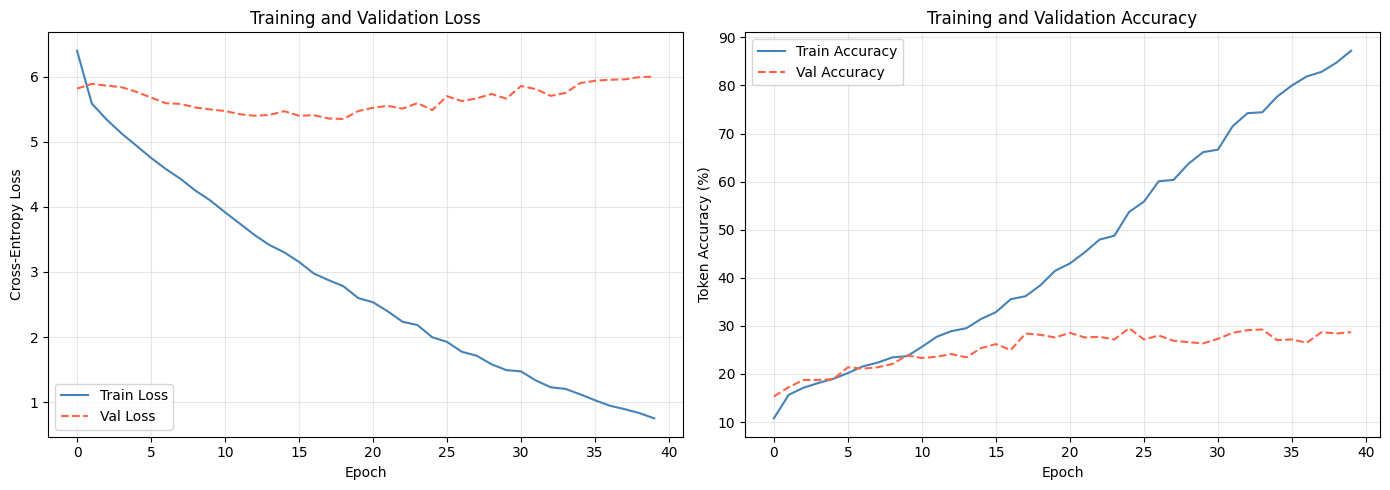

In [64]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(train_losses, label='Train Loss', color='steelblue')
ax1.plot(val_losses,   label='Val Loss',   color='tomato', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(train_accuracies, label='Train Accuracy', color='steelblue')
ax2.plot(val_accuracies,   label='Val Accuracy',   color='tomato', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Token Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('seq2seq_training_curves.png', dpi=150)
plt.show()

In [65]:
evaluate_and_show_examples(
    model       = model,
    src_val_t   = src_val_t,
    tgt_val_t   = tgt_val_t,
    src_vocab   = src_vocab,
    tgt_vocab   = tgt_vocab,
    device      = device,
    n_examples  = 5
)


Generating Evaluation Examples
Input                               Target                              Predicted                           Match  BLEU
------------------------------------------------------------------------------------------------------------------------
she won a tennis match              elle a gagné un match de tennis     porte une robe rouge                FAIL   0.0000
the organic market opens at <unk> on <unk> le marché biologique ouvre à <unk> le <unk> joue de la guitare dans les matins  FAIL   0.0000
we watch a movie together           nous regardons un film ensemble     travaille un repas                  FAIL   0.0583
the bread at this bakery is always <unk> le pain de cette boulangerie est toujours <unk> est est est incroyablement propre est FAIL   0.0293
we dance at the wedding             nous <unk> au mariage               reflète à la question               FAIL   0.0000
-----------------------------------------------------------------------------------

In [66]:
# ── Attention module
class BahdanauAttention(nn.Module):

    def __init__(self, hidden_size):
        super().__init__()
        self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.w_v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, query, keys, src_valid_lens=None):
        query  = query.unsqueeze(1)
        scores = self.w_v(torch.tanh(self.W_q(query) + self.W_k(keys))).squeeze(-1)

        if src_valid_lens is not None:
            max_len = keys.size(1)
            mask = torch.arange(max_len, device=keys.device).unsqueeze(0) \
                   >= src_valid_lens.unsqueeze(1)
            scores = scores.masked_fill(mask, -1e9)

        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), keys).squeeze(1)
        return context, weights


# ── Attention Decoder
class AttentionDecoder(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.attention = BahdanauAttention(hidden_size)
        self.embedding = nn.Embedding(vocab_size, embed_size,
                                      padding_idx=Vocabulary.PAD_IDX)
        self.rnn = nn.GRU(embed_size + hidden_size, hidden_size,
                          num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc      = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, enc_output, src_valid_lens):
        embedded = self.dropout(self.embedding(tgt_token.unsqueeze(1)))
        query    = hidden[-1]
        context, weights = self.attention(query, enc_output, src_valid_lens)
        rnn_input        = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        output, hidden   = self.rnn(rnn_input, hidden)
        logits           = self.fc(output.squeeze(1))
        return logits, hidden, weights


# ── Seq2Seq with Attention
class Seq2SeqAttention(nn.Module):

    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        tgt_vocab_size      = self.decoder.fc.out_features
        outputs             = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        enc_output, hidden = self.encoder(src)
        src_valid_lens     = (src != Vocabulary.PAD_IDX).sum(dim=1).to(self.device)
        input_token        = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder(input_token, hidden, enc_output, src_valid_lens)
            outputs[:, t]     = logits

            if random.random() < teacher_forcing_ratio:
                input_token = tgt[:, t]
            else:
                input_token = logits.argmax(1)

        return outputs

    def predict(self, src_tensor, max_len=20):
        self.eval()
        with torch.no_grad():
            enc_output, hidden = self.encoder(src_tensor)
            src_valid_lens     = (src_tensor != Vocabulary.PAD_IDX).sum(dim=1).to(self.device)
            input_token        = torch.tensor([Vocabulary.BOS_IDX]).to(self.device)
            predicted          = []
            all_weights        = []

            for _ in range(max_len):
                logits, hidden, weights = self.decoder(
                    input_token, hidden, enc_output, src_valid_lens
                )
                pred_idx = logits.argmax(1).item()

                if pred_idx == Vocabulary.EOS_IDX:
                    break

                predicted.append(pred_idx)
                all_weights.append(weights.squeeze(0).cpu())
                input_token = torch.tensor([pred_idx]).to(self.device)

        attn_matrix = torch.stack(all_weights, dim=0) if all_weights else None
        return predicted, attn_matrix

In [67]:
# ──  Problem 2
EMBED_SIZE    = 128
HIDDEN_SIZE   = 256
NUM_LAYERS    = 1
DROPOUT       = 0.4
LEARNING_RATE = 0.001
N_EPOCHS      = 40

encoder_attn = Encoder(
    vocab_size  = len(src_vocab),
    embed_size  = EMBED_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(device)

decoder_attn = AttentionDecoder(
    vocab_size  = len(tgt_vocab),
    embed_size  = EMBED_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(device)

model_attn     = Seq2SeqAttention(encoder_attn, decoder_attn, device).to(device)
optimizer_attn = torch.optim.Adam(model_attn.parameters(), lr=LEARNING_RATE)

print(f"Parameters: {sum(p.numel() for p in model_attn.parameters() if p.requires_grad):,}")
print(model_attn)

Parameters: 1,417,569
Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(894, 128, padding_idx=0)
    (rnn): GRU(128, 256, batch_first=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
  (decoder): AttentionDecoder(
    (attention): BahdanauAttention(
      (W_q): Linear(in_features=256, out_features=256, bias=False)
      (W_k): Linear(in_features=256, out_features=256, bias=False)
      (w_v): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(993, 128, padding_idx=0)
    (rnn): GRU(384, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=993, bias=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
)


In [68]:
import time
import copy

train_losses_attn     = []
val_losses_attn       = []
train_accuracies_attn = []
val_accuracies_attn   = []

best_val_loss_attn    = float('inf')
best_model_state_attn = None
best_epoch_attn       = 0

TEACHER_FORCING_START = 0.8
TEACHER_FORCING_END   = 0.2
N_EPOCHS = 40

for epoch in range(N_EPOCHS):
    start = time.time()

    teacher_forcing_ratio = TEACHER_FORCING_START - (
        (TEACHER_FORCING_START - TEACHER_FORCING_END) * epoch / (N_EPOCHS - 1)
    )

    # ── Training
    model_attn.train()
    epoch_loss    = 0.0
    correct_train = 0
    total_train   = 0

    for src_batch, tgt_batch in train_loader:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        optimizer_attn.zero_grad()

        outputs = model_attn(src_batch, tgt_batch,
                             teacher_forcing_ratio=teacher_forcing_ratio)

        loss = masked_cross_entropy(outputs[:, 1:], tgt_batch[:, 1:])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_attn.parameters(), max_norm=1.0)
        optimizer_attn.step()

        epoch_loss += loss.item()

        preds    = outputs[:, 1:].argmax(dim=-1)
        target   = tgt_batch[:, 1:]
        mask     = (target != Vocabulary.PAD_IDX)
        correct_train += (preds == target)[mask].sum().item()
        total_train   += mask.sum().item()

    avg_train_loss = epoch_loss / len(train_loader)
    avg_train_acc  = 100.0 * correct_train / total_train
    train_losses_attn.append(avg_train_loss)
    train_accuracies_attn.append(avg_train_acc)


    model_attn.eval()
    val_loss    = 0.0
    correct_val = 0
    total_val   = 0

    with torch.no_grad():
        for src_batch, tgt_batch in val_loader:
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            outputs = model_attn(src_batch, tgt_batch,
                                 teacher_forcing_ratio=0.0)

            loss = masked_cross_entropy(outputs[:, 1:], tgt_batch[:, 1:])
            val_loss += loss.item()

            preds    = outputs[:, 1:].argmax(dim=-1)
            target   = tgt_batch[:, 1:]
            mask     = (target != Vocabulary.PAD_IDX)
            correct_val += (preds == target)[mask].sum().item()
            total_val   += mask.sum().item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = 100.0 * correct_val / total_val
    val_losses_attn.append(avg_val_loss)
    val_accuracies_attn.append(avg_val_acc)


    if avg_val_loss < best_val_loss_attn:
        best_val_loss_attn    = avg_val_loss
        best_epoch_attn       = epoch + 1
        best_model_state_attn = copy.deepcopy(model_attn.state_dict())

    elapsed = time.time() - start
    print(f"Epoch {epoch+1:>3}/{N_EPOCHS} | TF: {teacher_forcing_ratio:.2f} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.2f}% | "
          f"Time: {elapsed:.1f}s")

print(f"\nBest model at epoch {best_epoch_attn} — Val Loss: {best_val_loss_attn:.4f}")
model_attn.load_state_dict(best_model_state_attn)


Epoch   1/40 | TF: 0.80 | Train Loss: 6.4605 | Train Acc: 11.03% | Val Loss: 6.0859 | Val Acc: 15.31% | Time: 0.6s
Epoch   2/40 | TF: 0.78 | Train Loss: 5.5922 | Train Acc: 15.23% | Val Loss: 6.0173 | Val Acc: 15.59% | Time: 0.6s
Epoch   3/40 | TF: 0.77 | Train Loss: 5.2565 | Train Acc: 17.33% | Val Loss: 5.9336 | Val Acc: 17.79% | Time: 0.6s
Epoch   4/40 | TF: 0.75 | Train Loss: 4.9554 | Train Acc: 19.49% | Val Loss: 5.7684 | Val Acc: 19.72% | Time: 0.6s
Epoch   5/40 | TF: 0.74 | Train Loss: 4.6841 | Train Acc: 21.07% | Val Loss: 5.6670 | Val Acc: 22.07% | Time: 0.5s
Epoch   6/40 | TF: 0.72 | Train Loss: 4.3932 | Train Acc: 23.40% | Val Loss: 5.5720 | Val Acc: 20.69% | Time: 0.6s
Epoch   7/40 | TF: 0.71 | Train Loss: 4.1638 | Train Acc: 25.04% | Val Loss: 5.5203 | Val Acc: 23.03% | Time: 0.6s
Epoch   8/40 | TF: 0.69 | Train Loss: 3.9368 | Train Acc: 27.47% | Val Loss: 5.4528 | Val Acc: 22.21% | Time: 0.6s
Epoch   9/40 | TF: 0.68 | Train Loss: 3.6844 | Train Acc: 30.03% | Val Loss: 5.4

<All keys matched successfully>

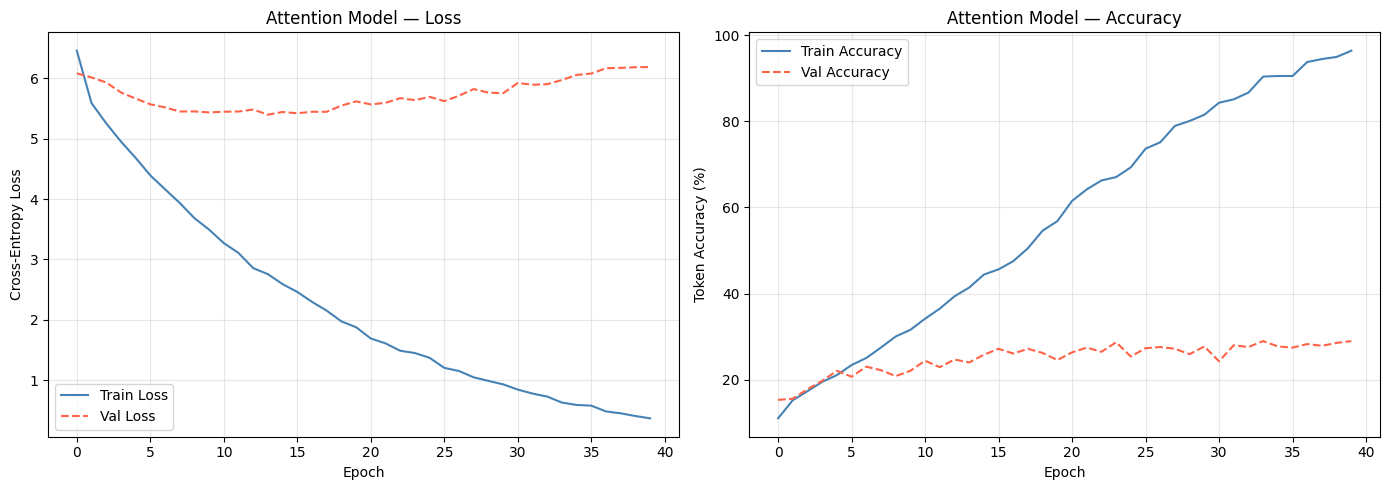

In [69]:
# ── Loss and accuracy curves ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_attn, label='Train Loss', color='steelblue')
ax1.plot(val_losses_attn,   label='Val Loss',   color='tomato', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Attention Model — Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accuracies_attn, label='Train Accuracy', color='steelblue')
ax2.plot(val_accuracies_attn,   label='Val Accuracy',   color='tomato', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Token Accuracy (%)')
ax2.set_title('Attention Model — Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('attn_training_curves.png', dpi=150)
plt.show()

In [70]:
# ── Evaluation (works for both baseline and attention model) ──────────────────
def evaluate_and_show_examples(model, src_val_t, tgt_val_t,
                                src_vocab, tgt_vocab, device, n_examples=5):
    model.eval()
    chencherry    = SmoothingFunction()
    correct_exact = 0
    total_bleu    = 0.0
    all_references  = []
    all_hypotheses  = []

    print("\n--- Generating Evaluation Examples ---")
    print(f"{'Input':<35} {'Target':<35} {'Predicted':<35} {'Match':<6} {'BLEU'}")
    print("-" * 120)

    with torch.no_grad():
        for i in range(len(src_val_t)):
            src_tensor = src_val_t[i].unsqueeze(0).to(device)

            result = model.predict(src_tensor, max_len=NUM_STEPS)
            pred_indices = result[0] if isinstance(result, tuple) else result

            src_words  = src_vocab.decode(src_val_t[i].tolist())
            tgt_words  = tgt_vocab.decode(tgt_val_t[i].tolist())
            pred_words = tgt_vocab.decode(pred_indices)

            exact_match = (pred_words == tgt_words)
            if exact_match:
                correct_exact += 1

            hypothesis = pred_words if pred_words else ['']
            bleu = sentence_bleu([tgt_words], hypothesis,
                                 smoothing_function=chencherry.method1)
            total_bleu += bleu
            all_references.append([tgt_words])
            all_hypotheses.append(hypothesis)

            if i < n_examples:
                match_str = "PASS" if exact_match else "FAIL"
                print(f"{' '.join(src_words)[:32]:<35} "
                      f"{' '.join(tgt_words)[:32]:<35} "
                      f"{' '.join(pred_words)[:32]:<35} "
                      f"{match_str:<6} {bleu:.4f}")

    print("-" * 120)
    n_total = len(src_val_t)
    print(f"\nFinal Global Metrics ({n_total} samples):")
    print(f"  -> Exact-Match Accuracy  : {correct_exact/n_total*100:.2f}% ({correct_exact}/{n_total})")
    print(f"  -> Avg Sentence BLEU-4   : {total_bleu/n_total:.4f}")
    print(f"  -> Corpus BLEU-4         : {corpus_bleu(all_references, all_hypotheses, smoothing_function=chencherry.method1):.4f}")


evaluate_and_show_examples(
    model     = model_attn,
    src_val_t = src_val_t,
    tgt_val_t = tgt_val_t,
    src_vocab = src_vocab,
    tgt_vocab = tgt_vocab,
    device    = device,
    n_examples = 5
)


--- Generating Evaluation Examples ---
Input                               Target                              Predicted                           Match  BLEU
------------------------------------------------------------------------------------------------------------------------
she won a tennis match              elle a gagné un match de tennis     a une un groupe de                  FAIL   0.0474
the organic market opens at <unk    le marché biologique ouvre à <un    vous plaît, à à à à                 FAIL   0.0293
we watch a movie together           nous regardons un film ensemble     a une un roman                      FAIL   0.0626
the bread at this bakery is alwa    le pain de cette boulangerie est    vous est est est à                  FAIL   0.0295
we dance at the wedding             nous <unk> au mariage               à la à la                           FAIL   0.0000
-------------------------------------------------------------------------------------------------------------

Input    : we watch a movie together
Predicted: a une un roman


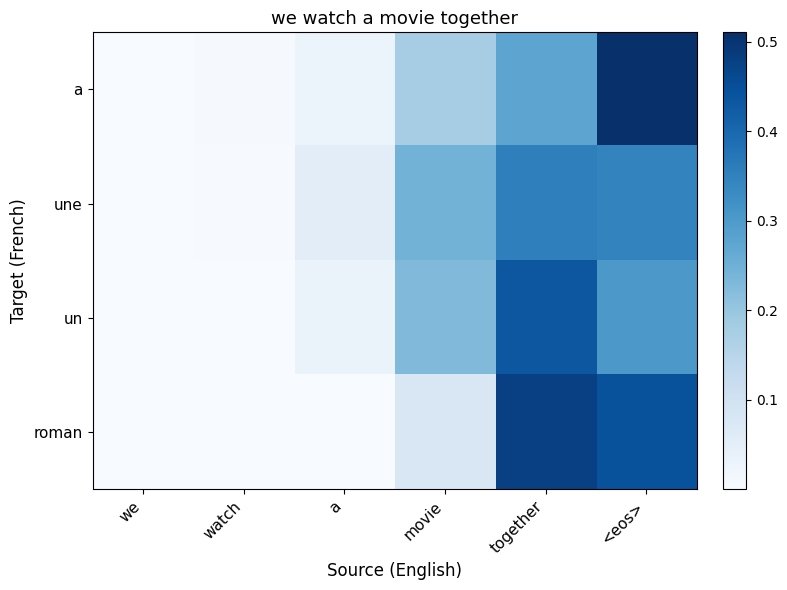

Input    : she speaks french fluently
Predicted: parlent couramment langues


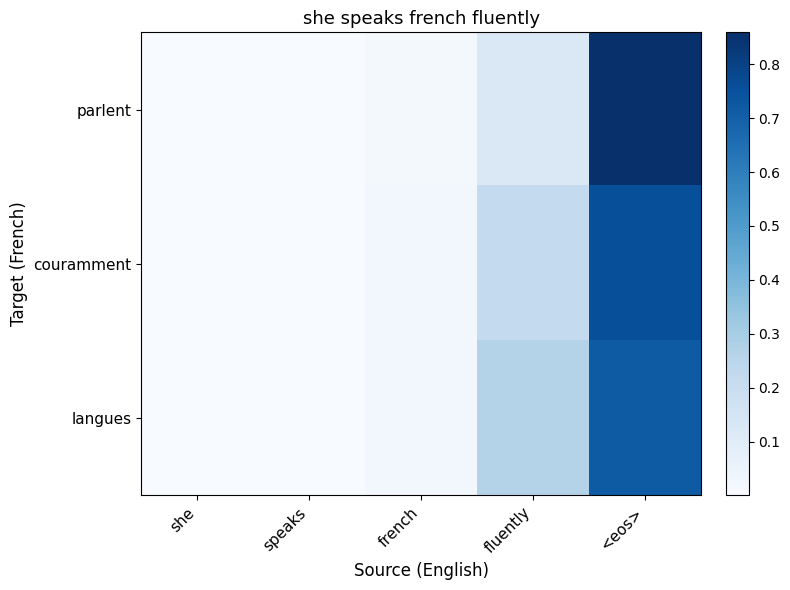

In [71]:
# ── Attention map visualization ───────────────────────────────────────────────
def plot_attention(attn_matrix, src_tokens, tgt_tokens, title="Attention Map"):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(attn_matrix.numpy(), cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=11)
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_yticklabels(tgt_tokens, fontsize=11)
    ax.set_xlabel("Source (English)", fontsize=12)
    ax.set_ylabel("Target (French)", fontsize=12)
    ax.set_title(title, fontsize=13)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(f"attn_map_{title[:30].replace(' ','_')}.png", dpi=150)
    plt.show()


def show_attention_for_sentence(model_attn, src_sentence_str,
                                src_vocab, tgt_vocab, device, num_steps):
    tokens  = src_sentence_str.lower().strip().split()
    encoded = src_vocab.encode(tokens) + [Vocabulary.EOS_IDX]
    if len(encoded) < num_steps:
        encoded += [Vocabulary.PAD_IDX] * (num_steps - len(encoded))
    else:
        encoded = encoded[:num_steps]

    src_tensor = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)
    pred_indices, attn_matrix = model_attn.predict(src_tensor, max_len=num_steps)
    pred_tokens = tgt_vocab.decode(pred_indices)

    print(f"Input    : {src_sentence_str}")
    print(f"Predicted: {' '.join(pred_tokens)}")

    if attn_matrix is not None and len(pred_tokens) > 0:
        src_display  = tokens + ['<eos>']
        attn_trimmed = attn_matrix[:, :len(src_display)]
        plot_attention(attn_trimmed, src_display, pred_tokens, title=src_sentence_str[:40])

    return pred_tokens


for sent in ["we watch a movie together", "she speaks french fluently"]:
    show_attention_for_sentence(model_attn, sent, src_vocab, tgt_vocab, device, NUM_STEPS)

In [72]:
evaluate_and_show_examples(
    model     = model_attn,
    src_val_t = src_val_t,
    tgt_val_t = tgt_val_t,
    src_vocab = src_vocab,
    tgt_vocab = tgt_vocab,
    device    = device,
    n_examples = 5
)


--- Generating Evaluation Examples ---
Input                               Target                              Predicted                           Match  BLEU
------------------------------------------------------------------------------------------------------------------------
she won a tennis match              elle a gagné un match de tennis     a une un groupe de                  FAIL   0.0474
the organic market opens at <unk    le marché biologique ouvre à <un    vous plaît, à à à à                 FAIL   0.0293
we watch a movie together           nous regardons un film ensemble     a une un roman                      FAIL   0.0626
the bread at this bakery is alwa    le pain de cette boulangerie est    vous est est est à                  FAIL   0.0295
we dance at the wedding             nous <unk> au mariage               à la à la                           FAIL   0.0000
-------------------------------------------------------------------------------------------------------------

In [74]:
# ── Reversed tensors: French → source, English → target
# For Problem 3 we simply swap them

# Re-encode with swapped roles
src_train_enc_r = [encode_and_pad(t, tgt_vocab, NUM_STEPS) for t in tgt_train]
src_val_enc_r   = [encode_and_pad(t, tgt_vocab, NUM_STEPS) for t in tgt_val]
tgt_train_enc_r = [encode_and_pad(s, src_vocab, NUM_STEPS) for s in src_train]
tgt_val_enc_r   = [encode_and_pad(s, src_vocab, NUM_STEPS) for s in src_val]

src_train_r = torch.tensor(src_train_enc_r, dtype=torch.long)
src_val_r   = torch.tensor(src_val_enc_r,   dtype=torch.long)
tgt_train_r = torch.tensor(tgt_train_enc_r, dtype=torch.long)
tgt_val_r   = torch.tensor(tgt_val_enc_r,   dtype=torch.long)

print(f"src_train_r (French input)   : {src_train_r.shape}")
print(f"tgt_train_r (English output) : {tgt_train_r.shape}")

train_dataset_r = TensorDataset(src_train_r, tgt_train_r)
val_dataset_r   = TensorDataset(src_val_r,   tgt_val_r)
train_loader_r  = DataLoader(train_dataset_r, batch_size=32, shuffle=True)
val_loader_r    = DataLoader(val_dataset_r,   batch_size=32, shuffle=False)

src_train_r (French input)   : torch.Size([444, 15])
tgt_train_r (English output) : torch.Size([444, 15])


In [75]:
# ── Problem 3A: Baseline GRU, reversed direction ─────────────────────────────
encoder_r = Encoder(
    vocab_size  = len(tgt_vocab),   # French vocab = 993
    embed_size  = EMBED_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(device)

decoder_r = Decoder(
    vocab_size  = len(src_vocab),   # English vocab = 894
    embed_size  = EMBED_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(device)

model_r     = Seq2Seq(encoder_r, decoder_r, device).to(device)
optimizer_r = torch.optim.Adam(model_r.parameters(), lr=LEARNING_RATE)

print(f"Parameters: {sum(p.numel() for p in model_r.parameters() if p.requires_grad):,}")
print(model_r)

Parameters: 1,260,798
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(993, 128, padding_idx=0)
    (rnn): GRU(128, 256, batch_first=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(894, 128, padding_idx=0)
    (rnn): GRU(384, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=894, bias=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
)


In [76]:
# ── Training loop
best_val_loss_r    = float('inf')
best_model_state_r = None
best_epoch_r       = 0
train_losses_r     = []
val_losses_r       = []
train_accuracies_r = []
val_accuracies_r   = []

for epoch in range(N_EPOCHS):
    start    = time.time()
    tf_ratio = TEACHER_FORCING_START - (
        (TEACHER_FORCING_START - TEACHER_FORCING_END) * epoch / (N_EPOCHS - 1)
    )

    model_r.train()
    epoch_loss, correct_train, total_train = 0.0, 0, 0

    for src_batch, tgt_batch in train_loader_r:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        optimizer_r.zero_grad()
        outputs = model_r(src_batch, tgt_batch, teacher_forcing_ratio=tf_ratio)
        loss    = masked_cross_entropy(outputs[:, 1:], tgt_batch[:, 1:])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_r.parameters(), max_norm=1.0)
        optimizer_r.step()

        epoch_loss    += loss.item()
        preds          = outputs[:, 1:].argmax(dim=-1)
        target         = tgt_batch[:, 1:]
        mask           = (target != Vocabulary.PAD_IDX)
        correct_train += (preds == target)[mask].sum().item()
        total_train   += mask.sum().item()

    avg_train_loss = epoch_loss / len(train_loader_r)
    avg_train_acc  = 100.0 * correct_train / total_train
    train_losses_r.append(avg_train_loss)
    train_accuracies_r.append(avg_train_acc)

    model_r.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for src_batch, tgt_batch in val_loader_r:
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)
            outputs   = model_r(src_batch, tgt_batch, teacher_forcing_ratio=0.0)
            loss      = masked_cross_entropy(outputs[:, 1:], tgt_batch[:, 1:])
            val_loss += loss.item()
            preds     = outputs[:, 1:].argmax(dim=-1)
            target    = tgt_batch[:, 1:]
            mask      = (target != Vocabulary.PAD_IDX)
            correct_val += (preds == target)[mask].sum().item()
            total_val   += mask.sum().item()

    avg_val_loss = val_loss / len(val_loader_r)
    avg_val_acc  = 100.0 * correct_val / total_val
    val_losses_r.append(avg_val_loss)
    val_accuracies_r.append(avg_val_acc)

    if avg_val_loss < best_val_loss_r:
        best_val_loss_r    = avg_val_loss
        best_epoch_r       = epoch + 1
        best_model_state_r = copy.deepcopy(model_r.state_dict())

    print(f"Epoch {epoch+1:>3}/{N_EPOCHS} | TF: {tf_ratio:.2f} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.2f}% | "
          f"Time: {time.time()-start:.1f}s")

print(f"\nBest model at epoch {best_epoch_r} | Val Loss: {best_val_loss_r:.4f}")
model_r.load_state_dict(best_model_state_r)

Epoch   1/40 | TF: 0.80 | Train Loss: 6.3403 | Train Acc: 12.25% | Val Loss: 5.8762 | Val Acc: 16.18% | Time: 0.3s
Epoch   2/40 | TF: 0.78 | Train Loss: 5.4735 | Train Acc: 17.15% | Val Loss: 5.8191 | Val Acc: 18.66% | Time: 0.4s
Epoch   3/40 | TF: 0.77 | Train Loss: 5.1795 | Train Acc: 19.59% | Val Loss: 5.7931 | Val Acc: 19.97% | Time: 0.4s
Epoch   4/40 | TF: 0.75 | Train Loss: 4.9364 | Train Acc: 21.46% | Val Loss: 5.7207 | Val Acc: 19.53% | Time: 0.3s
Epoch   5/40 | TF: 0.74 | Train Loss: 4.7136 | Train Acc: 22.20% | Val Loss: 5.6200 | Val Acc: 21.14% | Time: 0.3s
Epoch   6/40 | TF: 0.72 | Train Loss: 4.4891 | Train Acc: 24.64% | Val Loss: 5.5849 | Val Acc: 21.28% | Time: 0.4s
Epoch   7/40 | TF: 0.71 | Train Loss: 4.2678 | Train Acc: 25.63% | Val Loss: 5.6156 | Val Acc: 20.70% | Time: 0.3s
Epoch   8/40 | TF: 0.69 | Train Loss: 4.0921 | Train Acc: 27.07% | Val Loss: 5.5641 | Val Acc: 20.99% | Time: 0.3s
Epoch   9/40 | TF: 0.68 | Train Loss: 3.9619 | Train Acc: 27.78% | Val Loss: 5.5

<All keys matched successfully>

In [77]:
# Note: src_vocab and tgt_vocab are swapped for display
evaluate_and_show_examples(
    model     = model_r,
    src_val_t = src_val_r,
    tgt_val_t = tgt_val_r,
    src_vocab = tgt_vocab,   # French is now the source
    tgt_vocab = src_vocab,   # English is now the target
    device    = device,
    n_examples = 5
)


--- Generating Evaluation Examples ---
Input                               Target                              Predicted                           Match  BLEU
------------------------------------------------------------------------------------------------------------------------
elle a gagné un match de tennis     she won a tennis match              have a a a new                      FAIL   0.0537
le marché biologique ouvre à <un    the organic market opens at <unk    look to the the park                FAIL   0.0295
nous regardons un film ensemble     we watch a movie together           have a a                            FAIL   0.0583
le pain de cette boulangerie est    the bread at this bakery is alwa    look forward to the the park        FAIL   0.0293
nous <unk> au mariage               we dance at the wedding             is a new                            FAIL   0.0000
-------------------------------------------------------------------------------------------------------------

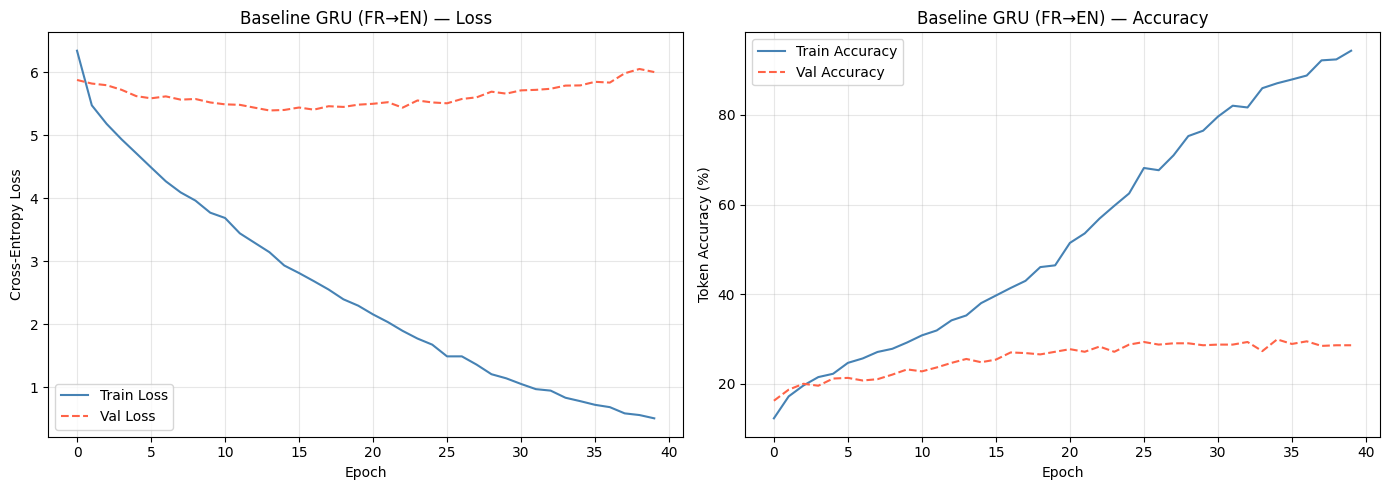

In [78]:
# ── Loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_r, label='Train Loss', color='steelblue')
ax1.plot(val_losses_r,   label='Val Loss',   color='tomato', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Baseline GRU (FR→EN) — Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accuracies_r, label='Train Accuracy', color='steelblue')
ax2.plot(val_accuracies_r,   label='Val Accuracy',   color='tomato', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Token Accuracy (%)')
ax2.set_title('Baseline GRU (FR→EN) — Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_reversed_curves.png', dpi=150)
plt.show()

In [79]:
# ── Problem 3B: Attention GRU, reversed direction
encoder_attn_r = Encoder(
    vocab_size  = len(tgt_vocab),   # French vocab = 993
    embed_size  = EMBED_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(device)

decoder_attn_r = AttentionDecoder(
    vocab_size  = len(src_vocab),   # English vocab = 894
    embed_size  = EMBED_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(device)

model_attn_r     = Seq2SeqAttention(encoder_attn_r, decoder_attn_r, device).to(device)
optimizer_attn_r = torch.optim.Adam(model_attn_r.parameters(), lr=LEARNING_RATE)

print(f"Parameters: {sum(p.numel() for p in model_attn_r.parameters() if p.requires_grad):,}")
print(model_attn_r)

Parameters: 1,392,126
Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(993, 128, padding_idx=0)
    (rnn): GRU(128, 256, batch_first=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
  (decoder): AttentionDecoder(
    (attention): BahdanauAttention(
      (W_q): Linear(in_features=256, out_features=256, bias=False)
      (W_k): Linear(in_features=256, out_features=256, bias=False)
      (w_v): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(894, 128, padding_idx=0)
    (rnn): GRU(384, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=894, bias=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
)


In [80]:
# ── Training loop — attention reversed
best_val_loss_ar    = float('inf')
best_model_state_ar = None
best_epoch_ar       = 0
train_losses_ar     = []
val_losses_ar       = []
train_accuracies_ar = []
val_accuracies_ar   = []

for epoch in range(N_EPOCHS):
    start    = time.time()
    tf_ratio = TEACHER_FORCING_START - (
        (TEACHER_FORCING_START - TEACHER_FORCING_END) * epoch / (N_EPOCHS - 1)
    )

    model_attn_r.train()
    epoch_loss, correct_train, total_train = 0.0, 0, 0

    for src_batch, tgt_batch in train_loader_r:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        optimizer_attn_r.zero_grad()
        outputs = model_attn_r(src_batch, tgt_batch, teacher_forcing_ratio=tf_ratio)
        loss    = masked_cross_entropy(outputs[:, 1:], tgt_batch[:, 1:])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_attn_r.parameters(), max_norm=1.0)
        optimizer_attn_r.step()

        epoch_loss    += loss.item()
        preds          = outputs[:, 1:].argmax(dim=-1)
        target         = tgt_batch[:, 1:]
        mask           = (target != Vocabulary.PAD_IDX)
        correct_train += (preds == target)[mask].sum().item()
        total_train   += mask.sum().item()

    avg_train_loss = epoch_loss / len(train_loader_r)
    avg_train_acc  = 100.0 * correct_train / total_train
    train_losses_ar.append(avg_train_loss)
    train_accuracies_ar.append(avg_train_acc)

    model_attn_r.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for src_batch, tgt_batch in val_loader_r:
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)
            outputs   = model_attn_r(src_batch, tgt_batch, teacher_forcing_ratio=0.0)
            loss      = masked_cross_entropy(outputs[:, 1:], tgt_batch[:, 1:])
            val_loss += loss.item()
            preds     = outputs[:, 1:].argmax(dim=-1)
            target    = tgt_batch[:, 1:]
            mask      = (target != Vocabulary.PAD_IDX)
            correct_val += (preds == target)[mask].sum().item()
            total_val   += mask.sum().item()

    avg_val_loss = val_loss / len(val_loader_r)
    avg_val_acc  = 100.0 * correct_val / total_val
    val_losses_ar.append(avg_val_loss)
    val_accuracies_ar.append(avg_val_acc)

    if avg_val_loss < best_val_loss_ar:
        best_val_loss_ar    = avg_val_loss
        best_epoch_ar       = epoch + 1
        best_model_state_ar = copy.deepcopy(model_attn_r.state_dict())

    print(f"Epoch {epoch+1:>3}/{N_EPOCHS} | TF: {tf_ratio:.2f} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.2f}% | "
          f"Time: {time.time()-start:.1f}s")

print(f"\nBest model at epoch {best_epoch_ar} | Val Loss: {best_val_loss_ar:.4f}")
model_attn_r.load_state_dict(best_model_state_ar)

Epoch   1/40 | TF: 0.80 | Train Loss: 6.3165 | Train Acc: 11.44% | Val Loss: 5.8015 | Val Acc: 16.18% | Time: 0.6s
Epoch   2/40 | TF: 0.78 | Train Loss: 5.4561 | Train Acc: 18.28% | Val Loss: 5.7699 | Val Acc: 18.66% | Time: 0.6s
Epoch   3/40 | TF: 0.77 | Train Loss: 5.1392 | Train Acc: 20.05% | Val Loss: 5.7377 | Val Acc: 21.57% | Time: 0.6s
Epoch   4/40 | TF: 0.75 | Train Loss: 4.8319 | Train Acc: 23.09% | Val Loss: 5.5791 | Val Acc: 22.30% | Time: 0.6s
Epoch   5/40 | TF: 0.74 | Train Loss: 4.5540 | Train Acc: 24.92% | Val Loss: 5.4661 | Val Acc: 23.62% | Time: 0.8s
Epoch   6/40 | TF: 0.72 | Train Loss: 4.2800 | Train Acc: 26.97% | Val Loss: 5.4131 | Val Acc: 22.59% | Time: 0.8s
Epoch   7/40 | TF: 0.71 | Train Loss: 4.0627 | Train Acc: 27.74% | Val Loss: 5.3453 | Val Acc: 23.03% | Time: 0.8s
Epoch   8/40 | TF: 0.69 | Train Loss: 3.8296 | Train Acc: 30.78% | Val Loss: 5.3158 | Val Acc: 24.20% | Time: 0.7s
Epoch   9/40 | TF: 0.68 | Train Loss: 3.7017 | Train Acc: 30.96% | Val Loss: 5.2

<All keys matched successfully>

In [81]:
# ── Evaluation — attention reversed
evaluate_and_show_examples(
    model     = model_attn_r,
    src_val_t = src_val_r,
    tgt_val_t = tgt_val_r,
    src_vocab = tgt_vocab,   # French is source
    tgt_vocab = src_vocab,   # English is target
    device    = device,
    n_examples = 5
)


--- Generating Evaluation Examples ---
Input                               Target                              Predicted                           Match  BLEU
------------------------------------------------------------------------------------------------------------------------
elle a gagné un match de tennis     she won a tennis match              bought a a new pair                 FAIL   0.0537
le marché biologique ouvre à <un    the organic market opens at <unk    are going to the the the            FAIL   0.0293
nous regardons un film ensemble     we watch a movie together           are a new                           FAIL   0.0583
le pain de cette boulangerie est    the bread at this bakery is alwa    is is looking for to the            FAIL   0.0348
nous <unk> au mariage               we dance at the wedding             are the                             FAIL   0.0334
-------------------------------------------------------------------------------------------------------------

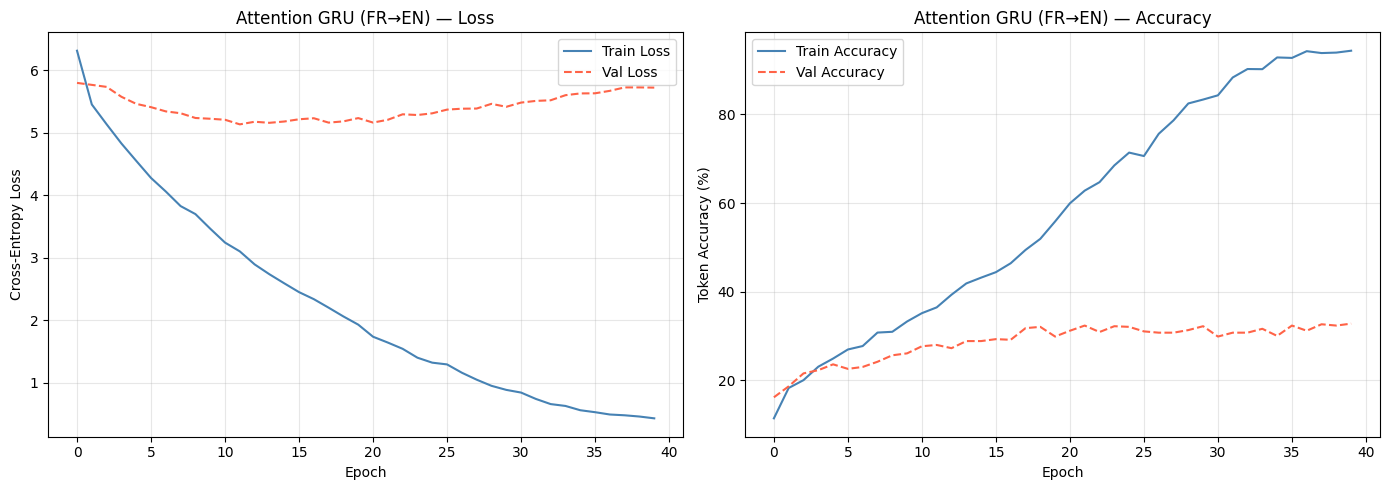

In [82]:
# ── Loss and accuracy curves — attention reversed ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_ar, label='Train Loss', color='steelblue')
ax1.plot(val_losses_ar,   label='Val Loss',   color='tomato', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Attention GRU (FR→EN) — Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accuracies_ar, label='Train Accuracy', color='steelblue')
ax2.plot(val_accuracies_ar,   label='Val Accuracy',   color='tomato', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Token Accuracy (%)')
ax2.set_title('Attention GRU (FR→EN) — Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('attn_reversed_curves.png', dpi=150)
plt.show()

Input    : elle parle français couramment
Predicted: is looking


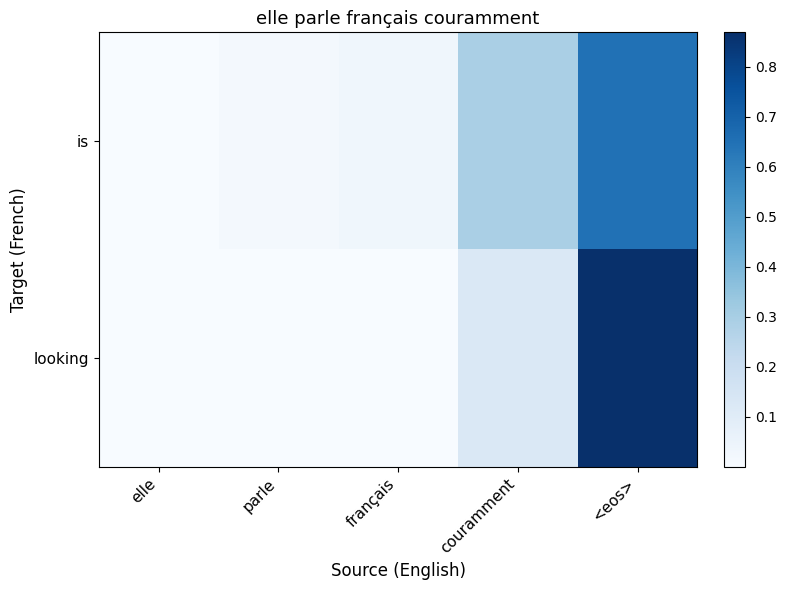

Input    : nous regardons un film ensemble
Predicted: are a new


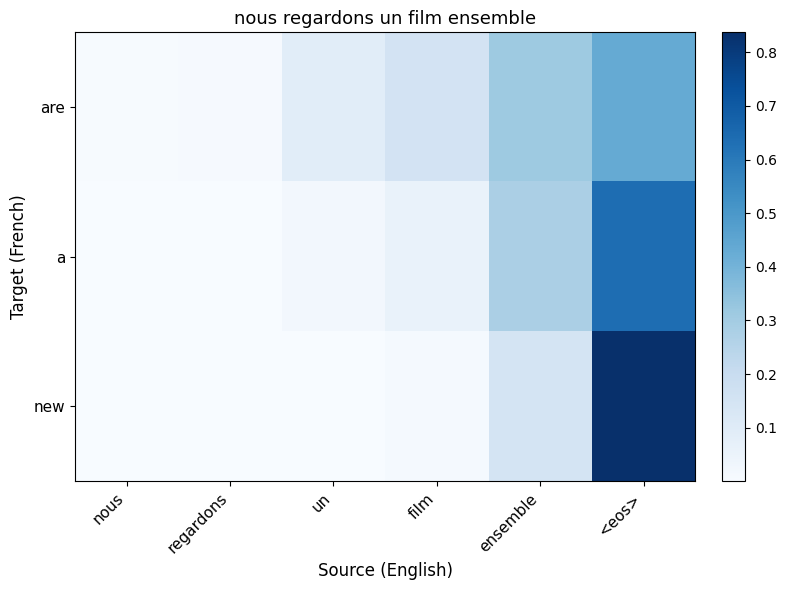

In [83]:
# ── Qualitative: attention maps for reversed direction
for sent in ["elle parle français couramment", "nous regardons un film ensemble"]:
    show_attention_for_sentence(
        model_attn       = model_attn_r,
        src_sentence_str = sent,
        src_vocab        = tgt_vocab,   # French vocab encodes the input
        tgt_vocab        = src_vocab,   # English vocab decodes the output
        device           = device,
        num_steps        = NUM_STEPS
    )